## <u>Import Libraries</u>

In [1]:
import pandas as pd
import numpy as np
import re  # regex, for text cleaning
import nltk # Natural Language Tool Kit
nltk.download("punkt")         
nltk.download("punkt_tab")
nltk.download("stopwords")
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from collections import Counter
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, random_split
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

[nltk_data] Downloading package punkt to /Users/apple/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /Users/apple/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /Users/apple/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


---
## <u>Load Dataset</u>

In [2]:
data = pd.read_csv("IMDB Dataset.csv")
data.drop_duplicates(inplace=True)  # modifies the original df instead of creating and returning a new one
data.shape  # (49582, 2)
print(data.head())
data["review"].str.split().str.len().describe()  # review lengths: informs max_len choice

                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


count    49582.000000
mean       231.350167
std        171.542020
min          4.000000
25%        126.000000
50%        173.000000
75%        281.000000
max       2470.000000
Name: review, dtype: float64

---
## <u>Text Preprocessing: worked example</u>

Every cleaning step below is shown on one real sentence first, so the transformation is visible before applying it to all ~49,000 reviews.

> "Fight Club is a really, really good movie. It's a slow burner, but the last 30 minutes of the movie are fabulous with one of the best plot twists in cinema history."

Six steps: lowercase, remove HTML, remove URLs, remove punctuation, remove stopwords, stemming.

### Step 1: lowercase

```
fight club is a really, really good movie. it's a slow burner, but the last 30
minutes of the movie are fabulous with one of the best plot twists in cinema history.
```

In [3]:
data["review"] = data["review"].str.lower()

### Step 2: remove HTML

This step runs **before** punctuation removal deliberately. Punctuation removal strips `<`/`>`, and by the time HTML removal would look for `<tag>` patterns, there would be nothing left to find. This example has no HTML tags, so it passes through unchanged here, but IMDB reviews often contain `<br /><br />` line breaks, which this step is for.

In [4]:
def remove_html(text):
    text = re.sub(r"<.*?>", "", text)  # . = any character, * = 0 or more, ? = non-greedy
    return text

data["review"] = data["review"].apply(remove_html)

### Step 3: remove URLs

No URLs in this example either, but the same principle applies dataset wide.

In [5]:
def remove_urls(text):
    text = re.sub(r"http\S+", "", text)  # \S+ = one or more non-whitespace characters (the whole URL)
    return text

data["review"] = data["review"].apply(remove_urls)  # .apply runs a custom function on every row

### Step 4: remove punctuation

```
fight club is a really really good movie its a slow burner but the last 30
minutes of the movie are fabulous with one of the best plot twists in cinema history
```
Commas, the period, and the apostrophe in "it's" are gone. `it's` becomes `its`.

In [6]:
def remove_punc(text):
    text = re.sub(r"[^A-Za-z0-9\s]", "", text)  # ^ means exclude everything in this set -- keep only letters, digits, whitespace
    return text

data["review"] = data["review"].apply(remove_punc)

### Step 5: remove stopwords

Tokenize first, then drop common low-meaning words (`is`, `a`, `its`, `but`, `the`, `of`, `are`, `with`, `in`). 32 tokens become 19:
```
['fight','club','really','really','good','movie','slow','burner','last','30',
 'minutes','movie','fabulous','one','best','plot','twists','cinema','history']
```

In [7]:
def remove_stopwords(text):
    tokens = word_tokenize(text)
    stop_words = stopwords.words("english")

    filtered_tokens = []  # will hold only the tokens we want to KEEP (non-stopwords)

    for token in tokens:
        if token not in stop_words:  # keep the token only if it's NOT a stopword
            filtered_tokens.append(token)

    return " ".join(filtered_tokens)  # rejoin the kept words into one string, separated by spaces

data["review"] = data["review"].apply(remove_stopwords)

### Step 6: stemming

Porter Stemmer reduces words to a rough base form, not always a real word, and that is expected. Still 19 tokens, several change:
```
['fight','club','realli','realli','good','movi','slow','burner','last','30',
 'minut','movi','fabul','one','best','plot','twist','cinema','histori']
```
`really` becomes `realli`, `movie` becomes `movi`, `minutes` becomes `minut`, `fabulous` becomes `fabul`, `twists` becomes `twist`, `history` becomes `histori`. The point is not readability: `movie` and `movies` both collapse to `movi`, so the model treats them as the same word.

In [8]:
def stemming(text):
    ps = PorterStemmer()
    stemmed_words = []
    tokens = word_tokenize(text)

    for token in tokens:
        stemmed_token = ps.stem(token)  # .stem() takes ONE string at a time
        stemmed_words.append(stemmed_token)

    return " ".join(stemmed_words)

data["review"] = data["review"].apply(stemming)

---
## <u>Encoding Labels</u>

In [9]:
le = LabelEncoder()
data["sentiment"] = le.fit_transform(data["sentiment"])
y = data["sentiment"]

---
## <u>Train Test Split: before building the vocabulary</u>

Same leakage principle as scaling and imputation on tabular data: the vocabulary should only be built from words the model would realistically have seen during training. Splitting **before** vocabulary building means the vocabulary never sees test set only words.

In [10]:
X_train_text, X_test_text, y_train, y_test = train_test_split( # using X_train_text and X_test_text here as we will need to make a new X_train/X_test later from these
    data["review"],
    y,
    test_size=0.2,
    random_state=42
)

---
## <u>Build Vocabulary: worked example</u>

vectorization is the general umbrella term for turning text into numbers at all. Bag of Words, TF-IDF, and embeddings are all forms of vectorization. Embedding specifically means a *dense, learned* vector, as opposed to BoW/TF-IDF's *sparse, counted* vectors. Embeddings are a type of vectorization, not a separate unrelated thing.

In the real pipeline, the vocabulary is built by counting every word across **all training reviews** and keeping the most frequent `vocab_size` of them. For illustration, here is the toy vocabulary the cleaned and stemmed example sentence would produce on its own (17 unique words plus 2 reserved slots):

```
0 = <PAD>      (padding filler)
1 = <UNK>      (a word not in the dictionary)
2 = fight    3 = club     4 = realli   5 = good     6 = movi
7 = slow     8 = burner   9 = last     10 = 30      11 = minut
12 = fabul   13 = one     14 = best    15 = plot    16 = twist
17 = cinema  18 = histori
```

The real vocabulary (below) works identically, just built from ~40,000 reviews instead of one sentence, and kept to the 5000 most frequent words.

In [11]:
def build_vocabulary(text, vocab_size=5000):  # text here is all the reviews in X_train_text cuz we dont want data leakage

    all_words = []  # collect every single word from every single review, duplicates included for counting

    for review in text:
        # word_tokenize breaks the review into tokens, .extend adds it in a flat 1d array
        all_words.extend(word_tokenize(review))

    # Counter tallies how many times each unique word appears, gives a dictionary object
    word_counts = Counter(all_words)

    # .most_common(n) returns the top n most frequent (word, count) pairs, sorted highest-first, as a list of tuples
    # -2 as we are reserving 2 index slots for <PAD> and <UNK> separately
    most_common_words = word_counts.most_common(vocab_size - 2)  

    # as we are customizing the dict, we need to hardcode the first 2 slots
    word_to_index = {
        "<PAD>": 0,
        "<UNK>": 1
    }

    # now we run the loop for every other index i.e. from 2 to 5000
    # Enumerate tracks both the index and the value of each item automatically
    for index, (word, count) in enumerate(most_common_words, start=2): 
        word_to_index[word] = index

    # return the final vocabulary dictionary
    return word_to_index

# Applying the function to get the vocabulary dictionary
word_to_index = build_vocabulary(X_train_text, vocab_size=5000)

---
## <u>Encode and Pad Reviews: worked example</u>

Two things happen to every review. First, each cleaned word is replaced with its vocabulary index. Second, every review is padded or truncated to the same fixed length so batches can be stacked into one rectangular tensor.

Using the toy vocabulary above, the example sentence's 19 cleaned tokens become:
```
[2, 3, 4, 4, 5, 6, 7, 8, 9, 10, 11, 6, 12, 13, 14, 15, 16, 17, 18]
```
With `max_len=20`, one `0` (`<PAD>`) is appended to reach the fixed length:
```
[2, 3, 4, 4, 5, 6, 7, 8, 9, 10, 11, 6, 12, 13, 14, 15, 16, 17, 18, 0]
```
A shorter review gets more `0`s appended. A longer one gets cut off at position 20.

**Choosing `max_len` for the real data:** the review length stats from the Load Dataset step showed a median of 173 words and a 75th percentile of 281, right skewed, with a long tail up to 2470. `max_len=250` covers the large majority of reviews in full while not forcing every batch to pad out to an extreme outlier's length.

In [12]:
def encode_review(text, word_to_index, max_length = 250): # text here again is the X_train reviews, word_to_index is the dict we made and max_length is already defined above

    # tokenization
    tokens = word_tokenize(text)
    
    # build indices, which is index of every token/word in our word_to_index dictionary, if the word isnt in it, we just put 1 as 1 is for <UNK>
    indices = []
    for token in tokens:
        if token in word_to_index:
            indices.append(word_to_index[token])
        else:
            indices.append(1)

    # if the review is shorter, we put 0 i.e. <PAD> in all the remaining indices in he indices list
    # if the review is longer, we just truncate it to our max_length that is 250
    if len(indices) < max_length:
        indices = indices + [0] * (max_length - len(indices)) # if the difference is 3, then add 3 zeros
    else:
        indices = indices[:max_length] # list slicing, it means from index 0 to index max length i.e. 250

    return indices

# Applying the function to get the X_train and X_test with proper indices built from the word_to_index dictionary
X_train = []
for text in X_train_text:
    coded_review = encode_review(text, word_to_index, max_length = 250)
    X_train.append(coded_review)

X_test = []
for text in X_test_text:
    coded_review = encode_review(text, word_to_index, max_length = 250)
    X_test.append(coded_review)

# converting into numpy array as it will be needed below
X_train = np.array(X_train)
X_test = np.array(X_test)
    

---
## <u>Dataset and DataLoader</u>

In [13]:
X_train_tensor = torch.tensor(X_train, dtype=torch.int64)  # nn.Embedding needs integer indices (LongTensor) to look up rows in its table, not floats
X_test_tensor = torch.tensor(X_test, dtype=torch.int64)    # so we put dtype as int64 to convert to integers

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

train_set = TensorDataset(X_train_tensor, y_train_tensor)
test_set = TensorDataset(X_test_tensor, y_test_tensor)

# carving a validation set out of the training data itself, not out of test_set
# this is what decides checkpointing during training, so test_set can stay fully unseen until the very end
train_set, val_set = random_split(
    train_set,
    [0.85,0.15],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_set, batch_size=128, shuffle=True)
val_loader = DataLoader(val_set, batch_size=64, shuffle=False)  # carved from training data, used for checkpointing
test_loader = DataLoader(test_set, batch_size=64, shuffle=False)  # only ever touched once, at final evaluation

---
## <u>Model Architecture</u>

This is a many to one architecture: it reads an entire sequence and produces a single output at the end, one sentiment prediction per review.

`nn.Embedding` turns each word-index integer into a learned vector (`embedding_dim` numbers, 100 here). This is what gives the LSTM a genuine sequence to process, timestep by timestep, instead of one collapsed vector.

The recurrent layer is `nn.LSTM`. A first attempt with plain `nn.RNN` on 250-timestep sequences got stuck around 50% accuracy, a coin flip. Training loss sat near 0.693 (`-ln(0.5)`, the loss value for a coin flip) and barely moved, matching the vanishing gradient problem: gradients could not flow back far enough through 250 timesteps of tanh for the network to learn anything. Swapping to LSTM, with no other change, brought test accuracy from ~50% to over 80%, a direct, working demonstration of the problem LSTM was built to solve. Plain RNN is not used again after this: LSTM is the default going forward.

LSTM tracks two states instead of one: the hidden state and the cell state. Both need their own zero-initialized starting tensor, and both get returned at the end as a pair, not a single tensor. Only the final hidden state is passed on to the classifier.

Shape journey (batch_size=64, vocab_size=5000, max_len=250, embedding_dim=100, hidden_size=128):
```
(64, 250)              64 reviews, 250 word-index integers each, in order
      |
      | nn.Embedding
      v
(64, 250, 100)          64 reviews, 250 real word-vectors each: goes into the LSTM
      |
      | self.lstm(x, (h0, c0)), h0 and c0 each shape (1, 64, 128)
      v
out:  (64, 250, 128)     hidden state at every one of the 250 timesteps
hn:   (1, 64, 128)       hidden state at only the final timestep: this is what gets kept
cn:   (1, 64, 128)       cell state at the final timestep: captured but not used further
      |
      | hn[-1]
      v
(64, 128)                last layer's final hidden state
      |
      | dropout(0.2), then self.fc: Linear(128 -> 1)
      v
(64, 1)                  final prediction per review
```

Dropout (0.2) sits inside `self.fc`, right before the linear layer, so it acts on the LSTM's final summary before classification, the same place dropout went in the earlier tabular builds.

In [14]:
class LSTM(nn.Module):

    # define constructor
    # here we wont just pass slef, but all the other variable/paramters as well 
    # vocab_size = size of word_to_index = 5000
    # embedding_dim = how many numbers represent each word
    # hidden_size = how many numbers the LSTM uses as its "memory" at each timestep
    # num_layers: how many LSTM layers stacked on top of each other.
    def __init__(self, vocab_size, embedding_dim = 100, hidden_size = 128, num_layers = 1):
        super(LSTM, self).__init__() # doubt, why dont we pass self,LSTM in the super?

        # saving these values into variables so that we can use it ahead
        self.embedding_dim = embedding_dim
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # the embedding layer
        # convert word-index integers into learned vectors
        # it is a lookup table, vocab_size rows tall, embedding_dim columns wide.
        # padding_idx = 0 tells PyTorch "index 0 is <PAD>
        self.embedding = nn.Embedding(vocab_size,embedding_dim, padding_idx = 0)

        # lstm layer
        # LSTM actually receives at every timestep is one embedding_dim-sized vector per word, not the original vocab_size
        # by default, pytorch expects the order of our inputs to be in format of (sequence_length, batch_size, input_size)
        # entire pipeline (and every dataset we will make) produces data shaped (batch_size, sequence_length, input_size) as that's how dataloader stacks samples
        # we do batch_first = True to do this and it does many size related computations like reshaping etc for us so that we dont need to do it later
        self.lstm = nn.LSTM(embedding_dim, hidden_size, num_layers, batch_first=True)

        # fully connected layer
        # it takes all the 128 hidden states and gives one binary output as positive or negative sentiment
        self.fc = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(hidden_size, 1)
        )
        
    def forward(self, x):
        
        # x arrives here as (batch_size, max_length) from data loader i.e. (64, 250)
        # Running it through self.embedding looks up each of those integers in the embedding table and replaces it with its vector
        # x comes out the other side reshaped to (batch_size, max_length, embedding_dim) i.e. (64,250,100)
        x_embed = self.embedding(x)

        # creating the hidden state and cell state for the first layer, both matrices full of zeros only
        # the shape will be (num_layers, batch_size, hidden_size)
        # x.size(0) grabs the batch size directly off the current batch
        # these are the inputs for our lstm layer
        hidden_state_0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        cell_state_0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)  # cell state, the conveyor belt

        # LSTM layer gives us 2 things, the full per-timestep history and the final (hidden state, cell state) pair
        # we throw away the full per-timestep history as its not needed in the many to 1 architecture
        # we also dont need the final cell state further, only the final hidden state goes to the fully connected layer
        timestep_history, (final_hidden_state, final_cell_state) = self.lstm(x_embed, (hidden_state_0, cell_state_0)) 

        # pass the final_hidden_state to the fully connected layer to get the label
        # final_output is not a probability yet, BCEWithLogitsLoss applies sigmoid internally during training
        # at evaluation time, we apply torch.sigmoid(final_output) manually to get an actual 0-1 probability
        # to pass to the fully connected layer, we need to drop the num_layers dimension first
        # tensor[i] (plain number, no colon) drops that dimension. tensor[i:j] (has a colon) keeps that dimension, just narrowed
        # tensor[-1] gives the deepest, most-processed layer's output in the nested list
        # tensor[0] gives the shallowest, the first sequence in the nested list
        final_output = self.fc(final_hidden_state[-1])
        
        
        return final_output

---
## <u>Compile the Model</u>

Three things needed here, same pattern as every prior build.

Instantiate the model: `LSTM(vocab_size)`. `vocab_size` comes from `len(word_to_index)`, not a hardcoded number, since it has to match the actual dictionary built earlier, including the `<PAD>` and `<UNK>` slots.

Loss function: `nn.BCEWithLogitsLoss()`. Binary sentiment (positive/negative), 1 output neuron, no activation on `fc`, sigmoid is applied internally by this loss function, same convention as the UFC and cat/dog binary builds.

Optimizer: `optim.Adam(model.parameters())`, same as every other build so far.

In [15]:
model = LSTM(len(word_to_index))

loss_func = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters())

---
## <u>Train the Model</u>

Same skeleton as the tabular ANN builds. The only genuinely new thing here is what comes out of the `DataLoader` each iteration.

Outer loop over epochs, `train_loss_history` and `val_loss_history` lists, `best_val_loss = float("inf")`, `best_epoch` tracker: identical to every previous project.

`model.train()` before the batch loop, `model.eval()` plus `torch.no_grad()` before the validation loop: identical.

Inner batch loop: `for x_batch, y_batch in train_loader:`. `x_batch` here is shape `(64, 250)`, word-index integers. `y_batch` is shape `(64, 1)`, float 0/1 labels. Nothing extra needed to prep them, the embedding lookup happens inside `forward()`, not out here.

`optimizer.zero_grad()`, then `model(x_batch)`, then `loss_func(y_pred, y_batch)`, then `.backward()`, then `.step()`: identical five step sequence to every build so far. `model(x_batch)` internally runs embedding, then LSTM, then dropout, then fc, exactly the `forward()` method written above.

Accumulate `total_train_loss`, divide by `len(train_loader)` at the end of each epoch: identical reasoning to before, average of per-batch averages.

Validation loop, same structure, over `test_loader` instead.

Checkpoint: `if avg_val_loss < best_val_loss:` then save `model.state_dict()` and track `best_epoch`.

In [16]:
epochs = 40
train_loss_history = []
val_loss_history = []
best_val_loss = float("inf")
best_epoch = 1

for epoch in range(epochs):

    model.train()
    total_train_loss = 0.0

    for x_batch, y_batch in train_loader:
        optimizer.zero_grad()

        y_pred_tensor = model(x_batch)
        batch_loss = loss_func(y_pred_tensor, y_batch)
        batch_loss.backward()
        optimizer.step()

        total_train_loss = total_train_loss + batch_loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    train_loss_history.append(avg_train_loss)

    model.eval()
    total_val_loss = 0.0

    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            y_pred_tensor = model(x_batch)
            batch_loss = loss_func(y_pred_tensor, y_batch)

            total_val_loss = total_val_loss + batch_loss.item()

    avg_val_loss = total_val_loss / len(val_loader)
    val_loss_history.append(avg_val_loss)

    print(f"epoch {epoch+1}/{epochs} ----------> training loss = {avg_train_loss} -----------> validation loss = {avg_val_loss}")

    if best_val_loss > avg_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), "best_lstm_model.pt")
        best_epoch = epoch + 1

print(f"best model at epoch : {best_epoch}")

epoch 1/40 ----------> training loss = 0.6929356555143992 -----------> validation loss = 0.6923873623212179
epoch 2/40 ----------> training loss = 0.6893276120677139 -----------> validation loss = 0.6919103155853927
epoch 3/40 ----------> training loss = 0.6800896866303502 -----------> validation loss = 0.6924293791094134
epoch 4/40 ----------> training loss = 0.665788792525277 -----------> validation loss = 0.7011726793422494
epoch 5/40 ----------> training loss = 0.6514590551907365 -----------> validation loss = 0.7132107916698661
epoch 6/40 ----------> training loss = 0.6196176384886106 -----------> validation loss = 0.6721692194220841
epoch 7/40 ----------> training loss = 0.6441934819925915 -----------> validation loss = 0.7261816942563621
epoch 8/40 ----------> training loss = 0.6338567440256928 -----------> validation loss = 0.7379364384117947
epoch 9/40 ----------> training loss = 0.6297420078154766 -----------> validation loss = 0.757647362447554
epoch 10/40 ----------> traini

---
## <u>Plot the Loss Curves</u>

Same as every prior build: `train_loss_history` and `val_loss_history` into a small DataFrame, then `plt.plot(...)`, training vs validation loss, labeled axes, legend.

The curve confirmed the vanishing gradient diagnosis directly. The plain RNN version never moved off a training loss near 0.693, while the LSTM version broke away from that baseline immediately and kept dropping. At 40 epochs, the curve also showed the overfitting stretch: validation loss bottoming out around epoch 16 then climbing while training loss kept falling, which is what the checkpoint logic above is for.

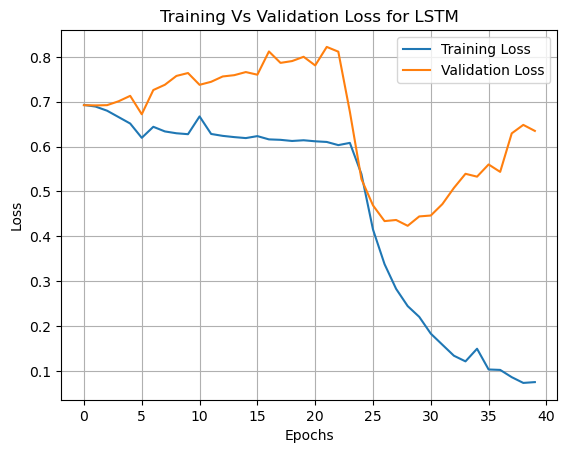

In [17]:
df_loss = pd.DataFrame({
    "Training loss" : train_loss_history,
    "Validation loss" : val_loss_history
})

plt.plot(df_loss["Training loss"], label="Training Loss")
plt.plot(df_loss["Validation loss"], label = "Validation Loss")

plt.title("Training Vs Validation Loss for LSTM")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show()

---
## <u>Load Best Checkpoint and Evaluate</u>

Load the checkpoint: `model.load_state_dict(torch.load(...))`, then `model.eval()` so dropout is switched off during evaluation.

Getting predictions follows the cat/dog CNN pattern, not the tabular one. The test set here (~10,000 reviews, each `(250,)` word indices, run through an embedding and an LSTM) is heavier per sample than tabular data, closer in spirit to the image case than to DateFruit's single-shot approach. This uses the same batch-accumulated evaluation pattern as CIFAR10 and cat/dog: loop over `test_loader` (and `train_loader`, to get both sets of metrics), collect predictions and labels batch by batch, `torch.cat` them together, compute metrics once on the full set, rather than pushing the entire set through `model(X_test_tensor)` in one shot.

Binary decision, not `argmax`: same reasoning as every binary build, 1 output neuron, so `torch.sigmoid(logits)` then `(probs >= 0.5).float()`.

Metrics: `accuracy_score`, `precision_score`, `recall_score`, `f1_score` on the concatenated predictions vs labels. No `average=` parameter needed since this is binary, not multiclass.

Checking `all_test_preds.unique(return_counts=True)` after the first (plain RNN) run showed almost every prediction landing on one class, confirming the model had collapsed rather than actually learning: the same signature as accuracy sitting at the baseline rate with recall near 1 and precision near the baseline rate. After the LSTM fix, the same check showed a roughly balanced split across both classes, consistent with a model making real, input-dependent predictions.

In [18]:
model.load_state_dict(torch.load("best_lstm_model.pt", weights_only = True))

model.eval()

# predictions
all_train_preds = []
all_test_preds = []

# answers
all_train_labels = []
all_test_labels = []

with torch.no_grad():
    for x_train_batch, y_train_batch in train_loader:
        
        y_pred_train_tensor = model(x_train_batch)                                  # raw logit
        train_probabilities = torch.sigmoid(y_pred_train_tensor)                    # turn raw logits into probabilities
        pred_train_classes = (train_probabilities >= 0.5).float()                   # turn probabilities into 0/1 predicted classes

        all_train_preds.append(pred_train_classes)
        all_train_labels.append(y_train_batch)

    for x_test_batch, y_test_batch in test_loader:

        y_pred_test_tensor = model(x_test_batch)
        test_probabilities = torch.sigmoid(y_pred_test_tensor)
        pred_test_classes = (test_probabilities >= 0.5).float()

        all_test_preds.append(pred_test_classes)
        all_test_labels.append(y_test_batch)

# concatenation
all_train_preds = torch.cat(all_train_preds)
all_test_preds = torch.cat(all_test_preds)
all_train_labels = torch.cat(all_train_labels)
all_test_labels = torch.cat(all_test_labels)

# evaluation
print("For Training:-")
print(f"Accuracy Score : {accuracy_score(all_train_labels.numpy(), all_train_preds.numpy())}")
print(f"Precision Score : {precision_score(all_train_labels.numpy(), all_train_preds.numpy())}")
print(f"Recall Score : {recall_score(all_train_labels.numpy(), all_train_preds.numpy())}")
print(f"F1 Score : {f1_score(all_train_labels.numpy(), all_train_preds.numpy())}")
print("\n")
print("For Testing:-")
print(f"Accuracy Score : {accuracy_score(all_test_labels.numpy(), all_test_preds.numpy())}")
print(f"Precision Score : {precision_score(all_test_labels.numpy(), all_test_preds.numpy())}")
print(f"Recall Score : {recall_score(all_test_labels.numpy(), all_test_preds.numpy())}")
print(f"F1 Score : {f1_score(all_test_labels.numpy(), all_test_preds.numpy())}")

For Training:-
Accuracy Score : 0.9333550836398149
Precision Score : 0.924322136786726
Recall Score : 0.9445822994210091
F1 Score : 0.9343424013090612


For Testing:-
Accuracy Score : 0.8311989512957547
Precision Score : 0.824557956777996
Recall Score : 0.8431096826034552
F1 Score : 0.83373063170441


In [19]:
all_test_preds.unique(return_counts=True)

(tensor([0., 1.]), tensor([4827, 5090]))